# Test - Train - Validation Sets

    -Train Dataset: Modeli oluşturmak için kullanılan veri kümesidir.
    -Validation set: Parametreleri düzenlemek için kullanılan veri kümesidir. Model eğitilirken validation verilerini görmez.
    -Test Dataset: Train dataset ile öğrenilen modeli test datası üzerinde deneyip, modelin değerlendirmeye yarar. Model test datasetindeki verileri görmeden eğitilir. 

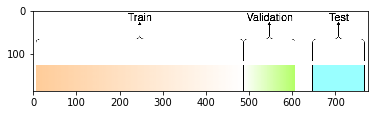

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image = mpimg.imread("images/split.png")
plt.imshow(image)
plt.show()

    -Cross-validation: 
    -Leave-one-out Validation

# Bewertungsmetriken (Evaluation Metrics)

### Sınıflandırma (Klassifikation)

Verwirrung Matrix (Confusion Matrix): 
    -c: sınıf sayısı ise bu matris cxc boyutundadır. Her sınıf değeri için kaç tanesinin hangi sınıf olarak sınıflandırıldığını gösterir. 
    -  |1 |2 |3
      1|15|0 |2  = 17
      2|1 |13|1  = 15
      3|0 |0 |12 = 12
      
      toplam veri sayısı: 44
      
0: negative class - hastalık var
1: positive class - hastalık yok

TP (True Positive): Modelin Positive sınıfa ait verileri doğru şekilde positive olarak tahminlenme durumu.

FP (False Positive): Modelin negatif verileri yanlışlıkla positive olarak tahmin etmesi

TN (True Negative): Modelin NEgative sınıfa ait verileri doğru şekilde negaitve olarak tahminlenme durumu.

FN (False Negative): Modelin pozitif verileri yanlışlıkla negatif olarak tahmin etmesi

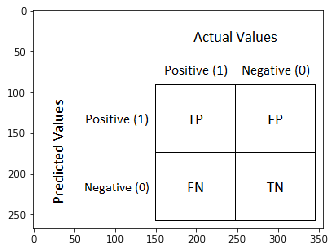

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image = mpimg.imread("images/confusionM.png")
plt.imshow(image)
plt.show()

Klassifikation Richtigkeit (classification accuracy): doğru tahmin edilen verilerin sayısının tüm veri sayısına oranı
#(TP+TN) / #Tüm dataset

Präzision und Erinnerung (Precision and Recall) 
Precision score: this is the measure of the accuracy, provided that a class label has been predicted. Simply put, it answers the following question, of all the classes, how many were correctly predicted? The answer to this question should be as high as possible. TP/TP+FP

Recall score(Sensitivity): This is the true positive rate that is if it predicts positive then how often does this take place?
TP/TP+FN

Recall ve Precision dengede olmalı. Bu değerlerin önemi probleme göre değişir. 
- Hastalık teşhisinde recall iyi çıksın isteyebiliriz. Hastalık teşhisi koyulan hastalar arasında doğru teşhis olanların sayısının fazla olması iyidir. 
- Video öneri programında amaç beğenilebilecek tüm videoların kullanıcıya gösterilmesidir. Bu yüzden kullanıcı ile ilgili videolar arasında doğru şekilde tavsiye edilenlerin sayısı yüksek olmalıdır. 

f1-Score: Precision ve recall arasındaki denge durumunu gözlemleyebilmek için kullanılır.

$$2 \frac{precision*recall}{precision+recall} $$


### Klasifikation Beispiel

46 29 0 0
Test
Accuracy: 1.0 
Recall: 1.0 
Precision 1.0
54 20 0 1
Train
Accuracy: 0.9866666666666667 
Recall: 0.9818181818181818 
Precision 1.0


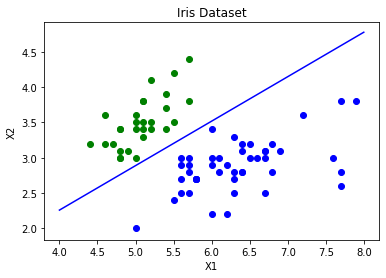

In [50]:
import sklearn.datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np 
import random

def loadData():
    iris = sklearn.datasets.load_iris()
    X = iris.data[:, :2]
    y = (iris.target != 0) * 1 #binary data
    bias = np.ones((X.shape[0],1))
    X = np.concatenate((bias,X), axis=1)
    #print(iris.target)
    #print(y)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50, random_state=42)
    '''
    print(X.shape)
    print(X_train.shape)  
    print(X_test.shape)
    print(y.shape)
    print(y_train.shape)
    print(y_test.shape)
    '''   
    return X_train, X_test, y_train, y_test

def plotScatter(x,y):
    plt.scatter(x[y == 0][:, 1], x[y == 0][:, 2], color='g', label='0')
    plt.scatter(x[y == 1][:, 1], x[y == 1][:, 2], color='b', label='1')
    plt.title('Iris Dataset')
    plt.xlabel('X1')
    plt.ylabel('X2')
    
def plotModel(w, c):
    # init. weights
    x1 = np.linspace(4,8)
    y = -(w[0] + w[1]*x1)/w[2]
    plt.plot(x1,y,c)
    
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def calErr(h, y):
    return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()

def update_weights(w, x, y, learning_rate, iter_val):
    m = len(y)
    
    for i in range(iter_val):
        z = np.dot(w,x.T)
        h = sigmoid(z)
        gradient_w = np.dot(x.T, (h - y)) / m
        w -= gradient_w*learning_rate
        
    return w

def evalualte(X_test,y_test, w):
    z = np.dot(w,X_test.T)
    h = sigmoid(z)
    tp =0
    fp =0
    tn =0
    fn =0
    for i in range(y_test.size):
        if y_test[i] == 1 and h[i] >= 0.5:
            tp += 1
        elif y_test[i] == 1 and h[i] < 0.5:
            fp += 1
        elif y_test[i] == 0 and h[i] > 0.5:
            fn += 1
        elif y_test[i] == 0 and h[i] <= 0.5:
            tn += 1

    print(tp,tn,fp,fn)
    acc = (tp + tn)/(y_test.size)
    recall = tp/(tp + fn)
    precision = tp/(tp + fp)
    
    return acc, recall, precision

if __name__ == "__main__":
    X_train, X_test, y_train, y_test = loadData()
    X = np.concatenate((X_train,X_test), axis = 0)
    y = np.concatenate((y_train,y_test), axis = 0)
    plotScatter(X_test,y_test)
    
    # Initialize weights
    w = np.random.rand(X_train.shape[1])
    # plotModel(w,'-r')
    
    # Update weights
    w = update_weights(w, X_train, y_train, 0.001, 300000)
    plotModel(w,'-b')
    
    # Evaluate model 
    acc, recall, precision = evalualte(X_test,y_test, w)
    print("Test")
    print("Accuracy:", acc, "\nRecall:", recall, "\nPrecision", precision)
    
    acc, recall, precision = evalualte(X_train,y_train, w)
    print("Train")
    print("Accuracy:", acc, "\nRecall:", recall, "\nPrecision", precision)

### Regresyon (Regression)

Mean Squared Error (MSE)

$ MSE = \frac{1}{N} \sum_{i}^{N} (y_i - h(x_i))^2 $

    -Regresyon analizi için kullanılan en yaygın metriklerden biridir. 
    -Yüksek değer çıkması modelin kötü olduğunu gösterir. Negatif değer çıkmaz. MSE 0 ise mükemmel model elde edilmiştir.
    -Outlier göz önünde bulundurur.

Root Mean Squared Error (RMSE)

$ RMSE = \sqrt {MSE} $

    -MSE kökü alınarak bulunur. Hata ölçeğini hedef değerlerin ölçeğine çeker. 

Mean Absolute Error (MAE)

$ MAE = \frac{1}{N} \sum_{i}^{N} |y_i - h(x_i)| $

R Squared (R²)

$ r = \frac{n(\sum xy)-(\sum x)(\sum y)}{\sqrt{[n\sum x^2 - (\sum x)^2][n\sum y^2 - (\sum y)^2]}} $

    -Linear regresyon modelinin ne kadar iyi olduğunu ölçer. 
    -0-100% arasında değer verir. 
    -Yüksek $R^2$ değeri regresyon modelin gözlemlenen veriler için iyi olduğunu gösterir. 

https://towardsdatascience.com/how-to-select-the-right-evaluation-metric-for-machine-learning-models-part-1-regrression-metrics-3606e25beae0

### Regression Beispiel

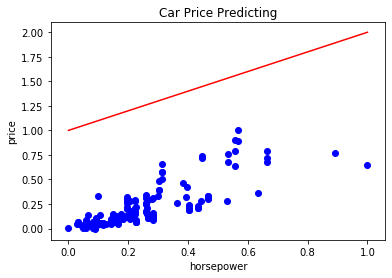

w: 1
b: 1
Error: 1.0914275206272004
w: 1.019964253584846
b: -0.034350439797871585
Error: 0.010075119542746836


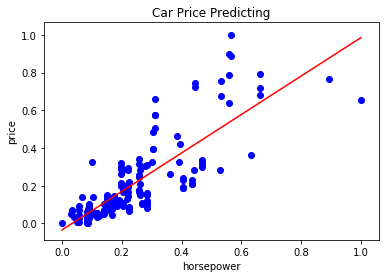

In [4]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import sys

def loadData():
    dataset = pd.read_csv('dataset/CarPrice_Assignment.csv')
    #print(dataset.shape) (205)
    #print(dataset.keys())
    x = dataset['horsepower']
    y = dataset['price']

    x_nor = (x - min(x)) / (max(x) - min(x))
    y_nor = (y - min(y)) / (max(y) - min(y))
    x = x_nor.tolist() 
    y = y_nor.tolist() 
    
    xTrain = x[:175]
    xTest = x[175:]
    yTrain = y[:175]
    yTest = y[175:]

    return xTrain,xTest,yTrain,yTest 
    
def plotScatter(x,y):
    plt.scatter(x,y, c='b')
    plt.title('Car Price Predicting')
    plt.xlabel('horsepower')
    plt.ylabel('price')

def plotModel(w, b):
    # init. weights
    x = np.linspace(0,1)
    y = w*x + b
    plt.plot(x,y,'-r')
    plt.show()

def MSE_cal(w, b, x, y):
    size = len(y)
    summ = 0
    
    for i in range(size):
        sub = y[i] - (w*x[i] + b)
        sq = sub ** 2
        summ += sq
    
    error = summ/float(size)
    return error

def update_weights(w, b, x, y, learning_rate, iter_val):

    for j in range(iter_val):
        w_der = 0
        b_der = 0
        N = len(x)
        for i in range(N):
            # Calculate partial derivatives
            # -2x(y - (wx + b))
            w_der += (-2/N)*x[i] * (y[i] - (w*x[i] + b))
            # -2(y - (wx + b))
            b_der += (-2/N)*(y[i] - (w*x[i] + b))

        # We subtract because the derivatives point in direction of steepest ascent
        w = w - w_der * learning_rate
        b = b - b_der * learning_rate

    return w, b

if __name__ == "__main__":
    xTrain,xTest,yTrain,yTest = loadData()
    
    w = 1
    b = 1
    plotScatter(xTrain,yTrain)
    plotModel(w,b)
    
    # calculate error
    err = MSE_cal(w, b, xTest, yTest)    
    print("w:",w)
    print("b:",b)
    print("Error:",err)
    
    w, b = update_weights(w, b, xTrain, yTrain, 0.001 ,iter_val=100000)
    
    # calculate error
    err = MSE_cal(w, b, xTest, yTest)    
    print("w:",w)
    print("b:",b)
    print("Error:",err)
    plotScatter(xTrain,yTrain)
    plotModel(w,b)